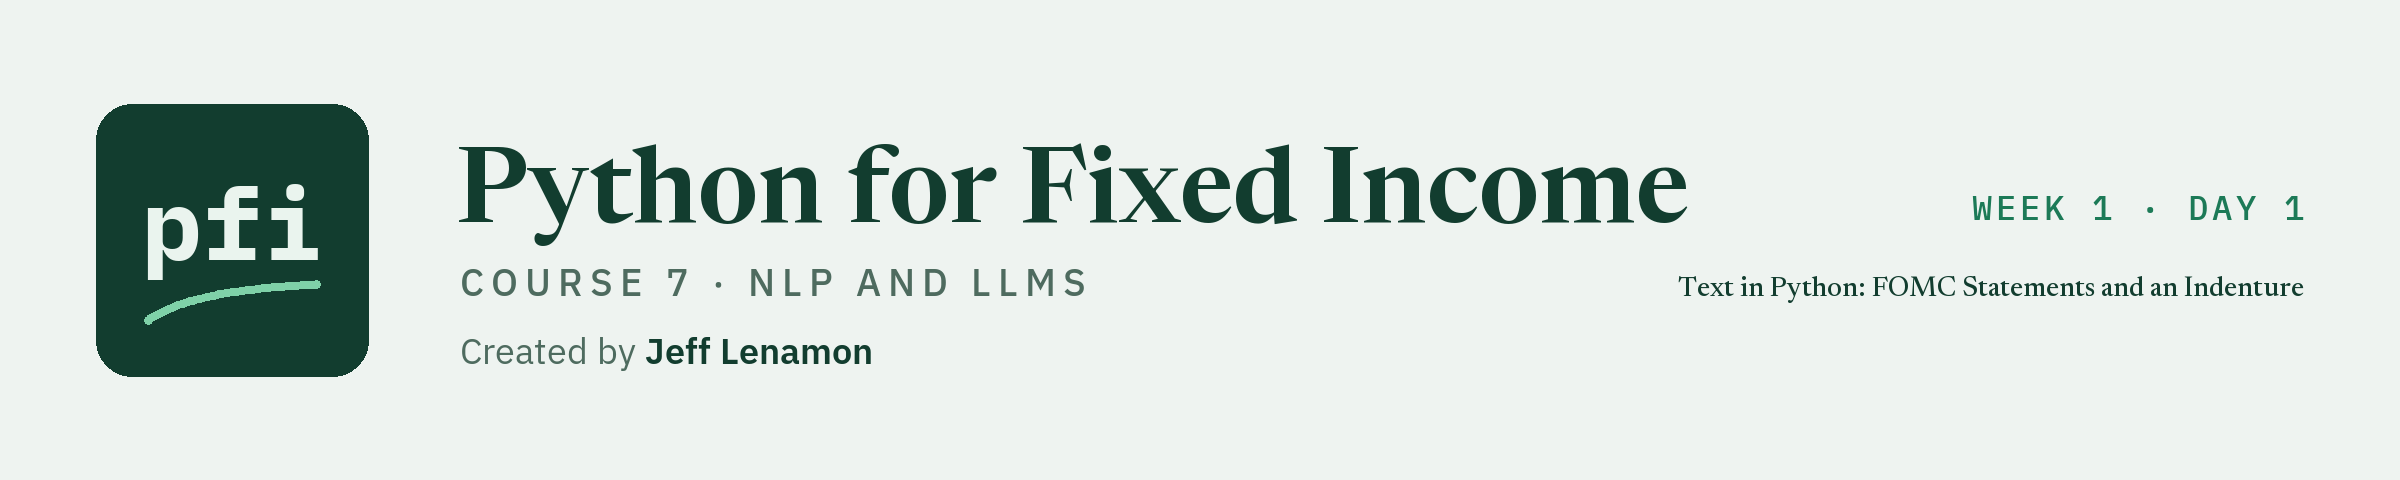

# Text in Python: FOMC Statements and an Indenture

Week 1, Day 1. Text is data too: today you read real text with Python, take numbers out of it with regular expressions, split it into tokens, and find the sections and defined terms of a real indenture.

**Data:** `course7_fomc_statements.csv`, 226 FOMC post-meeting statements, 2000-02-02 to 2026-09-16: **real**, Board of Governors of the Federal Reserve System, public domain (federalreserve.gov).

**Data:** `course7_indentures/boyd_2021.txt`: Boyd Gaming Corporation, Indenture dated as of June 8, 2021, 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495: **real**, a public record on sec.gov, quoted for descriptive extraction only.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course7_nlp_and_llms/week1/day1/01_text_in_python_fomc_statements_and_an_indenture.ipynb)

Courses 1 to 6 worked on numbers in tables. Most of what a credit desk reads is not a table: a central bank's statement, an issuer's 8-K, a 10-K's risk factors, and above all the indenture, the contract that holds a bond's covenants. Course 7 turns that text into data, one step at a time, and ends in week 3 with a tool that extracts an indenture's covenants and checks every number it extracts against the source text.

Today is the foundation: text as Python sees it. Two documents run through the notebook. The first is the file of FOMC post-meeting statements, 226 of them from 2000-02-02 to 2026-09-16. Course 1 counted words in the 46 statements from 2021; this file starts in 2000. The second is the indenture of Boyd Gaming Corporation's 4.750% Senior Notes due 2031, dated June 8, 2021, the course's teaching indenture for all three weeks.

**The rules for real documents, as on every day of this course.**

* **The documents are real.** The FOMC statements are the Board of Governors' own text, public domain. The indenture is a public record on sec.gov, filed by its issuer. Both are quoted exactly as published, with a source line under every excerpt.
* **Described, never judged.** A statement is never read for what the Committee meant, will do, or should do; a count from a statement is a count for a stated date. An indenture's terms are reported as the indenture states them, never called loose or tight, and no sentence compares issuers.
* **Issuer names appear only as the authors of the documents being read**: in the data line, the source line, and here.

**Rows.** No model is fitted or scored in this notebook: every number describes the 226 statements and the one indenture as published.

Today you will:

1. Treat a statement as a string: its length, slices, `in`, `lower`, `split`, `join`, and why `str.count` is not a word count.
2. Find the characters that look alike (the non-breaking hyphen, the curly apostrophe, the dashes) and make them plain with `normalize_text`.
3. Pull the target range, or the single target, out of every statement with regular expressions, and turn "5-3/4" into 5.75.
4. Split text into tokens with `tokenize`, and count them without the stop words.
5. Count the words of every statement by year, and draw it.
6. Open the indenture, find its sections with `find_sections`, and read Article 4's headings.
7. Find the defined terms of Section 1.01 with `defined_terms`, and the ones its pattern misses.
8. See what stemming would do, and why the course does not stem.

Q. Set up today's work folder: the thread settings, the quiet-loading settings, the seed, and today's two data files.

In [1]:
# today's setup: thread settings, quiet model loading, the modules, the seed, the course data, a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These lines must run before numpy, pandas, scikit-learn, or PyTorch is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# the model libraries print download bars and notices; these lines must run before they are imported
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("torch", "torch"), ("transformers", "transformers"), ("sentence_transformers", "sentence-transformers"), ("openai", "openai"), ("pydantic", "pydantic"), ("bs4", "beautifulsoup4"), ("pypdf", "pypdf"), ("pypdfium2", "pypdfium2"), ("dotenv", "python-dotenv"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course7_nlp_and_llms/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "torch": "2.14.1", "transformers": "5.19.0", "sentence-transformers": "6.1.0", "openai": "3.26.0", "pydantic": "2.13.5", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name].split("+")[0] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "course7_fomc_statements.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course7_01_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["course7_fomc_statements.csv", "course7_indentures/boyd_2021.txt"]
for name in DATA_FILES:
    (work / name).parent.mkdir(parents=True, exist_ok=True)
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, torch 2.14.1, transformers 5.19.0, sentence-transformers 6.1.0, openai 3.26.0, pydantic 2.13.5, pytest 9.1.1
Work folder: pfi_course7_01_1_jycjtm, in your temp folder
Data files from the data folder of the course repo: course7_fomc_statements.csv, course7_indentures/boyd_2021.txt
SEED = 42


The same cell opens every Course 7 notebook. Every line before `import numpy` is there for a reason:

* **Three thread settings**, as in Courses 4 to 6: one thread for the maths libraries, so every rerun adds its numbers up in the same order and prints the same digits.
* **Three quiet-loading settings.** From week 2 the course runs models from Hugging Face, a site that hosts pretrained models, through two libraries, `transformers` and `sentence-transformers`. Both print progress bars and notices while they load, and these three lines, set before either is imported, keep them off the screen. Today loads no model, so the lines change nothing yet; they sit in every setup cell so that no notebook ever depends on what ran before it.
* **The package check** stops with the install line for the first course package that is missing (in Colab, for example), before anything else runs.
* The version line, `SEED = 42`, the work folder, and the copies of today's two data files, as in Course 6. Today runs no model, so no PyTorch line appears; day 6's setup cell adds them.

Q. Write the earlier courses' modules today needs, unchanged: `mlkit.py`.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


* Course 4's `mlkit.py`, complete and unchanged. Course 7's module, `textkit.py`, starts today and **imports** `mlkit`, so later days can use its checks (the split checks and `assert_descriptive`) rather than writing them again.

## 1.1 Text Is a String

To Python a statement is a **string**: a sequence of characters, the same type as a ticker in Course 1. Everything in this section works on one string, the first statement in the file.

Q. Load the statements. How many are there, over which dates, and how many followed a scheduled meeting?

In [3]:
# one row per statement: its date, its page on federalreserve.gov, scheduled or not, and its text
fomc = pd.read_csv("course7_fomc_statements.csv")
print(f"statements: {len(fomc)}, from {fomc['date'].iloc[0]} to {fomc['date'].iloc[-1]}")
print(f"after a scheduled meeting: {fomc['scheduled'].sum()}; unscheduled releases: {(~fomc['scheduled']).sum()}")
print(f"columns: {list(fomc.columns)}")

statements: 226, from 2000-02-02 to 2026-09-16
after a scheduled meeting: 213; unscheduled releases: 13
columns: ['date', 'url', 'scheduled', 'text']


* 226 statements, 213 after scheduled meetings and 13 unscheduled releases made between them. Paragraphs are kept, separated by a newline.

> **STORY: why the file starts in 2000.** The Board's page of historical FOMC materials says: "The FOMC first announced the outcome of a meeting in February 1994. After making several further post-meeting statements in 1994, the Committee formally announced in February 1995 that all changes in the stance of monetary policy would be immediately communicated to the public. In January 2000, the Committee announced that it would issue a statement following each regularly scheduled meeting, regardless of whether there had been a change in monetary policy." The Board's answer to a question about FOMC meetings gives an earlier month for the same practice: "Since May 1999, the FOMC has issued statements following each meeting regardless of whether it changed policy." The course's file starts with the first statement of 2000, 2000-02-02, because its tool reads the Board's yearly pages from 2000 on. The two pages differ by a few months, and the course says no more than they do.
>
> Sources (read 2026-10-08): the Board's "Transcripts and other historical materials" page, https://www.federalreserve.gov/monetarypolicy/fomc_historical.htm, and its FAQ, https://www.federalreserve.gov/faqs/federal-open-market-committee-fomc-not-public.htm.

Q. Take the first statement. How long is it, and how does it start? Print the source line under it.

In [4]:
# source text: quoted as published
# a source line under every excerpt, computed from the row: the statement's date and its page
def statement_source(row):
    """The source line for one statement of the file."""
    return (f"Source: FOMC post-meeting statement of {row['date']}, Board of Governors of the Federal Reserve "
            f"System, {row['url']}")


first = fomc.iloc[0]
text = first["text"]
print(f"{len(text):,} characters")
# a slice: the characters from position 0 up to, not including, position 300
print(text[:300])
print(statement_source(first))

1,254 characters
The Federal Open Market Committee voted today to raise its target for the federal funds rate by 25 basis points to 5-3/4 percent. In a related action, the Board of Governors approved a 25 basis point increase in the discount rate to 5-1/4 percent.
The Committee remains concerned that over time incre
Source: FOMC post-meeting statement of 2000-02-02, Board of Governors of the Federal Reserve System, https://www.federalreserve.gov/boarddocs/press/general/2000/20000202/


* `len` counts characters: 1,254, spaces and newlines included. A long text is never printed whole in this course: a cell prints a slice, `text[:300]`, and the source line.
* Positions start at 0, as everywhere in Python, so `text[0]` is the first character and `text[:300]` the first 300.

Q. Does the statement mention inflation? Try `in` three ways.

In [5]:
# `in` asks whether one string occurs inside another, exactly as typed
print(f'"inflation" in text: {"inflation" in text}')
print(f'"Inflation" in text: {"Inflation" in text} (a capital I is another character)')
# lower() makes every letter lower case, so the question no longer depends on capitals
print(f'"inflation" in text.lower(): {"inflation" in text.lower()}')

"inflation" in text: True
"Inflation" in text: False (a capital I is another character)
"inflation" in text.lower(): True


* `in` is exact: a capital I is a different character. Lower-casing both sides first is the usual fix, and `tokenize` (section 1.4) does it for you.

Q. Split the statement into words, and join the first twelve back together.

In [6]:
# source text: quoted as published
# split() with no argument cuts at every run of spaces and newlines
words = text.split()
print(f"words by split(): {len(words)}")
print(f"the first twelve: {words[:12]}")
# join puts a string between the items of a list: here one space
print(" ".join(words[:12]))

words by split(): 188
the first twelve: ['The', 'Federal', 'Open', 'Market', 'Committee', 'voted', 'today', 'to', 'raise', 'its', 'target', 'for']
The Federal Open Market Committee voted today to raise its target for


* 188 pieces. `split` keeps punctuation on the word it touches, so "percent." with its full stop is one piece and "percent" another. Section 1.4 cuts the text into tokens instead.

Q. How often does "rate" occur? Compare `str.count` with a count of whole words.

In [7]:
# source text: quoted as published
# str.count counts the letters r-a-t-e wherever they occur, inside longer words too
print(f'text.count("rate"): {text.count("rate")}')
# the pieces of split() that are exactly "rate"
print(f'words that are exactly "rate": {words.count("rate")}')
print(f'pieces that hold "rate": {sorted({w for w in words if "rate" in w})}')

text.count("rate"): 6
words that are exactly "rate": 5
pieces that hold "rate": ['generate', 'rate']


* `str.count` gives 6; the whole word "rate" appears 5 times. The difference is the piece that merely contains the four letters: "generate". A substring count is not a word count, in Python or in Excel (Excel Side by Side shows the same trap with `SUBSTITUTE`).

## 1.2 Characters That Look Alike

Course 1 found a character in the statements that looks like a hyphen and is not one. Text copied from a web page carries several of these, and to Python each is a different character with its own number.

Q. Which characters outside ASCII do the statements hold, how often, and in which years?

In [8]:
import collections
import unicodedata

# every character above 127 (outside ASCII), counted over all statements
outside = collections.Counter(ch for t in fomc["text"] for ch in t if ord(ch) > 127)
rows = []
for ch in sorted(outside):
    dates = [d for d, t in zip(fomc["date"], fomc["text"]) if ch in t]
    # ord gives the character's number; U+ and four hex digits is how Unicode writes it
    rows.append({"code": f"U+{ord(ch):04X}", "name": unicodedata.name(ch), "times": outside[ch],
                 "statements": len(dates), "first": dates[0], "last": dates[-1]})
look_alikes = pd.DataFrame(rows).set_index("code")
print(look_alikes.to_string())

                               name  times  statements       first        last
code                                                                          
U+2011          NON-BREAKING HYPHEN     50          34  2015-07-29  2026-04-29
U+2013                      EN DASH      3           3  2026-06-17  2026-09-16
U+2014                      EM DASH      2           1  2020-03-15  2020-03-15
U+2019  RIGHT SINGLE QUOTATION MARK     25          19  2007-09-18  2022-05-04


* Four characters. The table prints each by its number and its Unicode name rather than the character itself, because on screen they look like `-` and `'`.
* **U+2011, the non-breaking hyphen**, appears 50 times in 34 statements from 2015 on. A web page uses it to keep "longer-term" on one line. U+2019 is the curly apostrophe of "Committee's"; U+2013 and U+2014 are the en dash and the em dash.

Q. Does the text "longer-term", typed with the hyphen on your keyboard, find every statement that says it?

In [9]:
# the hyphen on the keyboard is U+002D; "\u2011" writes the non-breaking hyphen in Python without typing it
plain, look_alike = "longer-term", "longer\u2011term"
print(f"statements with the plain hyphen: {sum(plain in t for t in fomc['text'])}")
print(f"statements with the non-breaking hyphen: {sum(look_alike in t for t in fomc['text'])}")
# ascii() shows any character outside ASCII as its escape, so the difference is visible
example = fomc.loc[fomc["date"] == "2021-01-27", "text"].iloc[0]
start = example.index(look_alike)
print(f"2021-01-27: {ascii(example[start - 20:start + 30])}")

statements with the plain hyphen: 102
statements with the non-breaking hyphen: 7
2021-01-27: 'rcent over time and longer\u2011term inflation expectat'


* 102 statements spell it with the plain hyphen and 7 with the non-breaking one. A search for "longer-term" misses those 7 statements, and nothing tells you. `ascii` shows the culprit as `\u2011`.
* The fix is to make the text plain before searching or counting it. That is the first function of `textkit`.

Q. Start `textkit.py` with `normalize_text`. Read the docstring first.

In [10]:
%%writefile textkit.py
"""textkit: text as data for fixed income, from a regular expression to a checked LLM extraction.

Written day by day in Python for Fixed Income, Course 7: NLP and LLMs.

Conventions, the same in every function:
- Text is normalized by normalize_text before it is counted, searched, or compared: Unicode NFC, a fixed map of
  look-alike characters (no-break space, non-breaking hyphen, curly quotes, dashes), one space for every run of
  white space, and one newline between paragraphs. Source files keep the text exactly as published.
- A token is a run of lower-case letters and digits, joined by single hyphens, apostrophes, or full stops
  (TOKEN_PATTERN): "mortgage-backed" and "4.750" are one token each, "1/4" is two. No stemming.
- Section numbers and 8-K item codes are text ("4.12", "2.04"), so "4.10" never becomes 4.1.
- Money is in US dollars as whole numbers of dollars (855_000_000); percentages are as the source writes them
  (15.0 means 15.0 percent); ratios are floats with the unit "x" (2.0 means 2.00 to 1.00).
- The seed is 42 wherever a function takes one.
- Every output describes what a document says. Nothing here is a forecast, a rating, or a credit view.
- Empty inputs, or inputs of the wrong shape, raise ValueError with a message that says what was wrong.
"""
import re  # regular expressions
import unicodedata  # Unicode normalization

import pandas as pd  # tables with labels

import mlkit  # Course 4's module, unchanged: the split checks and the description check

# one token: letters and digits, joined by single hyphens, apostrophes, or full stops
TOKEN_PATTERN = r"[a-z0-9]+(?:[-'.][a-z0-9]+)*"
# a section heading at the start of a line: "Section 4.12. Limitation on Indebtedness" or "SECTION 4.12"; the
# title, if any, starts with a capital letter or "[", so a cross-reference that starts a line ("Section 4.12(b)",
# "Section 4.13 or Section 4.19 of the Indenture") is not a heading
SECTION_PATTERN = (r"^[ \t]*(?:SECTION|Section)[ \t]+(?P<number>\d{1,2}\.\d{1,2})(?![\d(])\.?"
                   r"(?:[ \t]+(?P<title>[A-Z\[][^\n]*?))?[ \t]*(?:\.(?=[ \t]|$)|$)")
# look-alike characters and the plain character each becomes (COURSE7_SPEC.md, "Conventions")
CHARACTER_MAP = {
    "\u00a0": " ",  # no-break space
    "\u2010": "-",  # hyphen
    "\u2011": "-",  # non-breaking hyphen
    "\u2013": "-",  # en dash
    "\u2014": "-",  # em dash
    "\u2018": "'",  # left single quote
    "\u2019": "'",  # right single quote
    "\u201c": '"',  # left double quote
    "\u201d": '"',  # right double quote
}


def normalize_text(text: str) -> str:
    """Return text with look-alike characters made plain and white space tidied.

    Input: text, any string.
    Output: the text after three steps: Unicode NFC; each character of CHARACTER_MAP replaced by its plain form;
    every run of white space that holds a line break becomes one newline (a paragraph break), and every other run
    of white space becomes one space; no space or newline at either end.
    Convention: idempotent, so normalize_text(normalize_text(t)) == normalize_text(t). Run it on both sides of any
    comparison of text.
    Raises ValueError if text is not a string.
    """
    if not isinstance(text, str):
        raise ValueError(f"text must be a string, not {type(text).__name__}")
    # one code point per accented letter, then the fixed map
    text = unicodedata.normalize("NFC", text).translate(str.maketrans(CHARACTER_MAP))
    # a run of white space with a line break in it is a paragraph break; any other run is one space
    text = re.sub(r"[^\S\n]*\n\s*", "\n", text)
    text = re.sub(r"[^\S\n]+", " ", text)
    return text.strip()

Writing textkit.py


* The docstring at the top is the module's conventions, the same in every function: text is normalized before it is compared, a token is defined once, section numbers are text, money is in whole dollars. Every later day adds to this file.
* `CHARACTER_MAP` holds each look-alike and the plain character it becomes; `str.translate` swaps them all in one pass. Then every run of white space with a line break in it becomes one newline (a paragraph break), and every other run one space.
* `TOKEN_PATTERN` and `SECTION_PATTERN` are the patterns of sections 1.4 and 1.6, kept at the top so every function uses the same one.
* `import mlkit` loads Course 4's module.

Q. Start `test_textkit.py` with two tests: the map, and idempotence (running it twice changes nothing).

In [11]:
%%writefile test_textkit.py
"""Tests for textkit.py. Run in the folder that holds textkit.py and mlkit.py:  python -m pytest -q test_textkit.py

The tests use small texts typed here, never a course data file, and never the network or a key.
"""
import pytest

import textkit

INDENTURE = (
    "TABLE OF CONTENTS\n"
    "Section 1.01 Definitions\n"
    "Section 4.10 Change of Control\n"
    "Section 4.12 Limitation on Indebtedness\n"
    "ARTICLE 1\n"
    "Section 1.01. Definitions.\n"
    '"Indebtedness" means any obligation for borrowed money.\n'
    '"Notes" has the meaning set forth in the recitals.\n'
    "ARTICLE 4\n"
    "Section 4.10. Change of Control. Upon a Change of Control, each Holder may require a repurchase.\n"
    "Section 4.12. Limitation on Indebtedness. The Company shall not Incur any Indebtedness.\n"
)


def test_normalize_text_map():
    text = "longer\u2011term \u201cNotes\u201d \u2018a\u2019 4\u00a0to\u20135\u20146"
    assert textkit.normalize_text(text) == "longer-term \"Notes\" 'a' 4 to-5-6"


def test_normalize_text_idempotent():
    text = "  First  paragraph.\r\n\r\n  Second\tline \u00a0 here.  \n"
    once = textkit.normalize_text(text)
    assert once == "First paragraph.\nSecond line here."
    assert textkit.normalize_text(once) == once

Writing test_textkit.py


* `INDENTURE` is a small text typed for the tests, in the shape of an indenture: a table of contents, then the body. The tests of sections 1.6 and 1.7 use it. textkit's tests never read a course data file.
* The source of every cell in this course is plain ASCII, so the tests write the look-alikes as escapes (`\u2011`), never as the characters themselves.

Q. Import the modules, and run the tests.

In [12]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import textkit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(textkit)

# the functions defined in textkit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(textkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "textkit" and not name.startswith("_")
             and not isinstance(obj, type)]
print(f"textkit functions: {len(functions)}")

textkit functions: 1


In [13]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..                                                                       [100%]
2 passed in 1.36s



* `2 passed`.

Q. Print the map, and count what is left outside ASCII after `normalize_text`.

In [14]:
# each look-alike by its number and name, and the plain character it becomes
for ch, plain_ch in textkit.CHARACTER_MAP.items():
    print(f"U+{ord(ch):04X} {unicodedata.name(ch):30} becomes {plain_ch!r}")

normalized = [textkit.normalize_text(t) for t in fomc["text"]]
print(f"characters outside ASCII after normalize_text: {sum(ord(ch) > 127 for t in normalized for ch in t)}")
print(f'statements with "longer-term" after normalize_text: {sum("longer-term" in t for t in normalized)}')

U+00A0 NO-BREAK SPACE                 becomes ' '
U+2010 HYPHEN                         becomes '-'
U+2011 NON-BREAKING HYPHEN            becomes '-'
U+2013 EN DASH                        becomes '-'
U+2014 EM DASH                        becomes '-'
U+2018 LEFT SINGLE QUOTATION MARK     becomes "'"
U+2019 RIGHT SINGLE QUOTATION MARK    becomes "'"
U+201C LEFT DOUBLE QUOTATION MARK     becomes '"'
U+201D RIGHT DOUBLE QUOTATION MARK    becomes '"'
characters outside ASCII after normalize_text: 0
statements with "longer-term" after normalize_text: 109


* After `normalize_text` nothing outside ASCII is left in the statements, and "longer-term" is found in 109 statements, all of them. The source file keeps the Board's characters exactly as published; normalizing happens in code, every time, on both sides of a comparison.

## 1.3 Regular Expressions

A **regular expression** is a pattern for text: `\d` is any digit, `+` means one or more, `(...)` captures what it matches as a group, and `|` means or. Python's `re` module runs them. They are the main tool of this week: a pattern pulls a number out of a sentence however many times the sentence appears.

Q. In the first statement, find the size of the move in basis points, every "... percent", and every "inflation" in any case.

In [15]:
# source text: quoted as published
import re

# re.search: the first match, or None; group(1) is what the first (...) captured
move = re.search(r"by (\d+) basis points", text)
print(f"re.search: {move.group(0)!r}, group 1 {move.group(1)!r}")
# re.findall: every match, as a list of strings
percents = re.findall(r"[\d/-]+ percent", text)
print(f"re.findall: {percents}")
# re.IGNORECASE makes the pattern ignore capitals
inflation_words = re.findall(r"inflation\w*", text, flags=re.IGNORECASE)
print(f"inflation, any case: {inflation_words}")

re.search: 'by 25 basis points', group 1 '25'
re.findall: ['5-3/4 percent', '5-1/4 percent']
inflation, any case: ['inflationary', 'inflation']


* `re.search` returns a match object: `group(0)` is the whole match, `group(1)` the first group, as text. `[\d/-]+` is a **character class**: one or more of a digit, a slash, or a hyphen, which is how the statements write "5-3/4".
* `inflation\w*` takes the letters after "inflation" too, so "inflationary" comes back whole.

Q. Every statement states either a single target for the federal funds rate (before December 2008) or a target range. Write one pattern for each wording, and pull the rate out of every statement.

In [16]:
# a rate as the statements write it: "5-3/4", "1 3/4" (with a space), "1/4", or a whole number
NUMBER = r"(?:\d+[- ]\d+/\d+|\d+/\d+|\d+)"
# "the target range for the federal funds rate [by 1/4 percentage point] at|to|of LOW to HIGH percent"
RANGE = (rf"target range for the federal funds rate(?: by {NUMBER} percentage point,?)? (?:at|to|of) "
         rf"(?P<low>{NUMBER}) to (?P<high>{NUMBER}) percent")
# "the current 0 to 1/4 percent target range"
CURRENT = rf"(?P<low>{NUMBER}) to (?P<high>{NUMBER}) percent target range"
# "its target for the federal funds rate ... to|at TARGET percent", the wording before December 2008
TARGET = rf"target for the federal funds rate[^.]*? (?:to|at) (?P<target>{NUMBER}) percent"


def stated_rate(text, normalize=True):
    """The target range or single target a statement states, as written: (kind, low, high)."""
    clean = textkit.normalize_text(text) if normalize else text
    for pattern in (RANGE, CURRENT):
        found = re.search(pattern, clean)
        if found:
            return "range", found["low"], found["high"]
    found = re.search(TARGET, clean)
    if found:
        return "target", found["target"], found["target"]
    return "none", None, None


rates = pd.DataFrame([stated_rate(t) for t in fomc["text"]], columns=["kind", "low", "high"])
rates.insert(0, "date", fomc["date"])
print(rates["kind"].value_counts().to_string())
print(f"last single target: {rates.loc[rates['kind'] == 'target', 'date'].iloc[-1]}; "
      f"first range: {rates.loc[rates['kind'] == 'range', 'date'].iloc[0]}")
none = fomc.loc[rates["kind"] == "none"]
print(f"statements with neither: {len(none)}, unscheduled: {(~none['scheduled']).sum()}")

kind
range     144
target     76
none        6
last single target: 2008-10-29; first range: 2008-12-16
statements with neither: 6, unscheduled: 6


* `(?P<low>...)` is a **named group**: `found["low"]` reads it by name. `(?:...)` groups without capturing, so `NUMBER` can sit inside other patterns. `[^.]*?` means "any characters but a full stop, as few as possible": it lets the older wording put "by 25 basis points" between the target and the rate.
* 144 statements state a range and 76 a single target; the last single target is 2008-10-29 and the first range 2008-12-16. Every scheduled statement states one or the other. The 6 that state neither are all unscheduled releases, and their text names no target or range.
* The patterns were written by reading the wordings, then checked on every statement: a pattern is a claim about how a document is written, and the counts above are the test of the claim.

Q. What do the same patterns find on the text as published, without `normalize_text`?

In [17]:
# the same function on the raw text
raw = pd.DataFrame([stated_rate(t, normalize=False) for t in fomc["text"]], columns=["kind", "low", "high"])
missed = (rates["kind"] == "range") & (raw["kind"] != "range")
print(f"ranges found on the normalized text: {(rates['kind'] == 'range').sum()}, on the raw text: {(raw['kind'] == 'range').sum()}")
print(f"missed on the raw text: {missed.sum()}, of which hold U+2011: {fomc.loc[missed, 'text'].str.contains(chr(0x2011)).sum()}")

ranges found on the normalized text: 144, on the raw text: 132
missed on the raw text: 12, of which hold U+2011: 12


* 12 ranges are lost on the raw text, every one in a statement that writes a fraction with the non-breaking hyphen ("1-1/2" with U+2011). `\d+-` asks for the keyboard hyphen. Nothing fails; the rows quietly come back as "none". That is why `normalize_text` runs before every pattern in this course.

Q. Turn the written rates into numbers of percent, and check the function against a hand table first.

In [18]:
def written_to_number(written):
    """A rate as the statements write it ("5-3/4", "1 3/4", "1/4", "6") as a number of percent (5.75)."""
    if "/" not in written:
        return float(written)
    # "5-3/4" and "1 3/4": the whole part, then the fraction; "1/4" has no whole part
    whole, _, fraction = written.replace(" ", "-").rpartition("-")
    top, bottom = fraction.split("/")
    return (float(whole) if whole else 0.0) + int(top) / int(bottom)


# the hand table: worked on paper before the function was trusted
hand = {"5-3/4": 5.75, "1 3/4": 1.75, "1/4": 0.25, "0": 0.0, "6": 6.0, "4-1/2": 4.5}
for written, number in hand.items():
    assert written_to_number(written) == number, f"{written}: {written_to_number(written)}, not {number}"
print(f"{len(hand)} hand values checked")

stated = rates["kind"] != "none"
rates.loc[stated, "low_percent"] = rates.loc[stated, "low"].map(written_to_number)
rates.loc[stated, "high_percent"] = rates.loc[stated, "high"].map(written_to_number)
show = ["2000-02-02", "2002-05-07", "2008-10-29", "2008-12-16", "2017-12-13", "2026-09-16"]
print(rates.set_index("date").loc[show].to_string())

6 hand values checked
              kind    low   high  low_percent  high_percent
date                                                       
2000-02-02  target  5-3/4  5-3/4         5.75          5.75
2002-05-07  target  1 3/4  1 3/4         1.75          1.75
2008-10-29  target      1      1         1.00          1.00
2008-12-16   range      0    1/4         0.00          0.25
2017-12-13   range  1-1/4  1-1/2         1.25          1.50
2026-09-16   range  3-3/4      4         3.75          4.00


* The hand table covers every shape the patterns return, including the spaced "1 3/4" of 5 statements in 2002 (from 2002-05-07), which a pattern written only for "1-3/4" would have missed.
* A single target fills both columns with the same number, so every stated row has a low and a high. The last statement in the file states 3.75 to 4 percent. These are the numbers the statements state, by date; nothing here reads them for what came next.

## 1.4 Tokens

`split` gave pieces with punctuation glued on. A **token** is the unit a program counts: here, a run of letters and digits, lower case, that may be joined by single hyphens, apostrophes, or full stops. Every count, TF-IDF vector, and classifier in weeks 1 and 2 starts from tokens, so the rule is written once, in `textkit`.

Q. Add `tokenize` to `textkit.py`, and its two tests.

In [19]:
%%writefile -a textkit.py


def tokenize(text: str, lower: bool = True) -> list[str]:
    """Split text into tokens with TOKEN_PATTERN, after normalize_text.

    Inputs: text; lower, True to lower-case first (the course's default; GloVe and TF-IDF are lower case).
    Output: the tokens in the order they appear. With lower=False the pattern runs ignoring case and each token
    keeps its case. A text with no letter or digit gives an empty list.
    Convention: "mortgage-backed", "longer-term", "4.750", and "company's" are one token each; "1/4" is two
    ("1", "4"), because a slash is not a joiner. No stop words are removed and no word is stemmed.
    Raises ValueError if text is not a string.
    """
    text = normalize_text(text)
    if lower:
        return re.findall(TOKEN_PATTERN, text.lower())
    return re.findall(TOKEN_PATTERN, text, flags=re.IGNORECASE)

Appending to textkit.py


In [20]:
%%writefile -a test_textkit.py


def test_tokenize_keeps_hyphenated_words():
    # the ASCII hyphen and the non-breaking hyphen give the same single token
    assert textkit.tokenize("mortgage-backed") == ["mortgage-backed"]
    assert textkit.tokenize("mortgage\u2011backed") == ["mortgage-backed"]


def test_tokenize_hand_sentence():
    sentence = "The Committee's target range is 4-1/4 to 4-1/2 percent; the 4.750% Notes are due 2031."
    assert textkit.tokenize(sentence) == ["the", "committee's", "target", "range", "is", "4-1", "4", "to", "4-1",
                                          "2", "percent", "the", "4.750", "notes", "are", "due", "2031"]
    assert textkit.tokenize("The Notes", lower=False) == ["The", "Notes"]

Appending to test_textkit.py


* `tokenize` runs `normalize_text` first, so the two hyphens give one token, then `re.findall(TOKEN_PATTERN, ...)`. The pattern `[a-z0-9]+(?:[-'.][a-z0-9]+)*` reads: letters and digits, then any number of (a joiner and more letters and digits). So "mortgage-backed", "committee's", and "4.750" are one token each, and a full stop at the end of a sentence is never part of one.
* A slash is not a joiner, so "1/4" is two tokens, "1" and "4". The hand test spells out every token of one sentence, including "4-1" from "4-1/4": tokens are for counting words, and section 1.3's patterns are for reading numbers.

Q. Reload `textkit` and run the tests.

In [21]:
# the file changed, so reload before using the new function
importlib.reload(textkit)
print(f"tokenize in textkit: {hasattr(textkit, 'tokenize')}")

tokenize in textkit: True


In [22]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

....                                                                     [100%]
4 passed in 1.37s



* `4 passed`.

Q. Tokenize the first statement, and two short phrases.

In [23]:
# source text: quoted as published
tokens = textkit.tokenize(text)
print(f"tokens: {len(tokens)} (split() gave {len(words)} pieces)")
print(f"the first twelve: {tokens[:12]}")
print(textkit.tokenize("agency mortgage-backed securities"))
print(textkit.tokenize("0 to 1/4 percent"))

tokens: 190 (split() gave 188 pieces)
the first twelve: ['the', 'federal', 'open', 'market', 'committee', 'voted', 'today', 'to', 'raise', 'its', 'target', 'for']
['agency', 'mortgage-backed', 'securities']
['0', 'to', '1', '4', 'percent']


* 190 tokens against 188 pieces, lower case and with no punctuation.

Q. What are the most frequent tokens in all 226 statements, once the **stop words** ("the", "of", "and") are left out?

In [24]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

all_tokens = [token for t in fomc["text"] for token in textkit.tokenize(t)]
print(f"tokens in all statements: {len(all_tokens):,}; distinct: {len(set(all_tokens)):,}")
# scikit-learn's list of English stop words: frequent words that say little on their own
print(f"stop words in scikit-learn's list: {len(ENGLISH_STOP_WORDS)}; "
      f"share of the tokens that are stop words: {sum(t in ENGLISH_STOP_WORDS for t in all_tokens) / len(all_tokens):.4f}")
# Counter counts each distinct item; most_common lists the largest counts first
counts = collections.Counter(t for t in all_tokens if t not in ENGLISH_STOP_WORDS)
print(pd.DataFrame(counts.most_common(15), columns=["token", "count"]).to_string(index=False))
print(f'"mortgage-backed" as one token: {all_tokens.count("mortgage-backed")} times')

tokens in all statements: 86,576; distinct: 1,910
stop words in scikit-learn's list: 318; share of the tokens that are stop words: 0.3776
     token  count
 committee   1601
 inflation   1415
  economic    952
   federal    869
      rate    829
    policy    755
   percent    703
    market    681
conditions    538
         2    529
     funds    503
  monetary    498
securities    461
     labor    458
     range    457
"mortgage-backed" as one token: 215 times


* 86,576 tokens, 1,910 distinct. Stop words are 37.8 percent of all tokens, so leaving them out changes which tokens look frequent. The course uses scikit-learn's list of 318 words wherever a day removes stop words; it never edits the list by hand.
* The most frequent token without stop words is "committee" (1,601 times), then "inflation" (1,415). These are counts of words in the statements, nothing more; day 2 weights them.
* `collections.Counter` is a dictionary of counts. Day 5 builds a score from counts like these.

## 1.5 The Statements Got Longer

Q. Count the tokens of every statement, and summarise them by year.

In [25]:
fomc["tokens"] = [len(textkit.tokenize(t)) for t in fomc["text"]]
fomc["year"] = fomc["date"].str[:4].astype(int)
by_year = fomc.groupby("year")["tokens"].agg(["count", "median"])
print(by_year.T.to_string())
longest = fomc.loc[fomc["tokens"].idxmax()]
print(f"longest statement: {longest['date']}, {longest['tokens']} tokens; shortest: {fomc['tokens'].min()} tokens")

year     2000   2001   2002   2003   2004   2005   2006   2007   2008   2009   2010   2011   2012   2013   2014   2015   2016   2017   2018   2019   2020   2021   2022   2023   2024   2025   2026
count     8.0   11.0    8.0    8.0    8.0    8.0    8.0   10.0   11.0    8.0    9.0    8.0    8.0    8.0    8.0    8.0    8.0    8.0    8.0    9.0   10.0    8.0    8.0    8.0    8.0    8.0    6.0
median  178.0  215.0  186.5  208.5  268.5  274.0  219.0  175.0  287.0  426.0  443.0  461.5  473.0  700.5  822.5  575.0  572.0  515.5  326.5  351.0  456.0  487.5  369.5  341.0  347.0  333.0  232.0
longest statement: 2014-09-17, 896 tokens; shortest: 79 tokens


Q. Draw every statement's token count by date, with the median of each year.

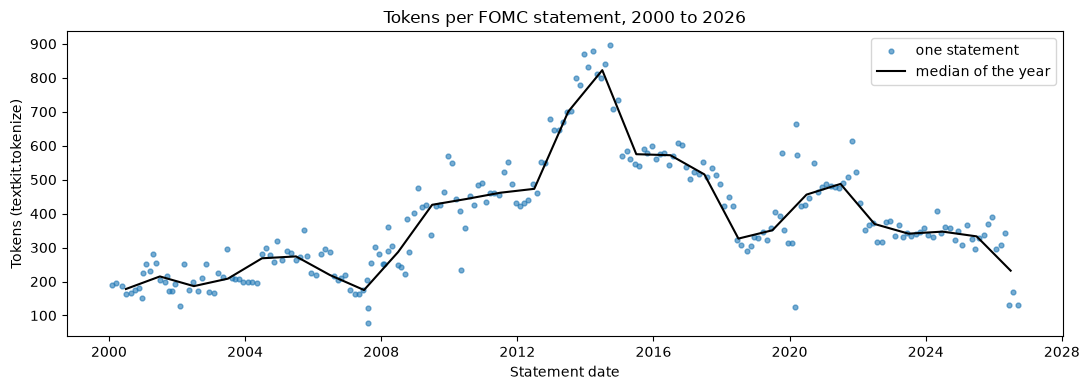

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
dates = pd.to_datetime(fomc["date"])
ax.scatter(dates, fomc["tokens"], s=12, alpha=0.6, label="one statement")
middle_of_year = pd.to_datetime(by_year.index.astype(str) + "-07-01")
ax.plot(middle_of_year, by_year["median"], color="black", label="median of the year")
ax.set_title("Tokens per FOMC statement, 2000 to 2026")
ax.set_xlabel("Statement date")
ax.set_ylabel("Tokens (textkit.tokenize)")
ax.legend()
plt.tight_layout()
plt.show()

* The median statement had 178 tokens in 2000 and 175 in 2007, rose to 822.5 in 2014, the highest median of any year, and was 232 in 2026 (6 statements so far). The longest single statement is 2014-09-17's, 896 tokens.
* This describes the documents: how many tokens each one holds, by date. The notebook does not say why the length changed; the statements' text does not say, and a count cannot.

## 1.6 A First Look at an Indenture

An **indenture** is the contract between a bond's issuer and a trustee acting for the holders. It defines its terms, sets out the notes, and in its covenants article says what the issuer may and may not do. Course 7's teaching indenture is Boyd Gaming Corporation's for the 4.750% Senior Notes due 2031: the text of Exhibit 4.1 to an 8-K, as filed on sec.gov and turned into plain text by the course's tool (day 9 writes that step).

Q. Load the indenture. How long is it, and how does it start?

In [27]:
# source text: quoted as published
# the course's source line for this indenture, and a section when one is shown
BOYD = ("Boyd Gaming Corporation, indenture for the 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed "
        "2021-06-08, accession 0001193125-21-185495")


def boyd_source(section=None):
    """The source line for an excerpt of the Boyd indenture."""
    return f"Source: {BOYD}" + (f", Section {section}." if section else ".")


indenture = Path("course7_indentures/boyd_2021.txt").read_text(encoding="utf-8")
print(f"characters: {len(indenture):,}; words by split(): {len(indenture.split()):,}; "
      f"tokens: {len(textkit.tokenize(indenture)):,}; lines: {len(indenture.splitlines()):,}")
print(indenture[:700])
print(boyd_source())

characters: 392,021; words by split(): 63,595; tokens: 63,810; lines: 1,714
EX-4.1 2 d185267dex41.htm EX-4.1
EX-4.1
Exhibit 4.1
Execution Version
BOYD GAMING CORPORATION
AND
THE GUARANTORS NAMED HEREIN
4.750% SENIOR NOTES DUE 2031
INDENTURE
Dated as of June 8, 2021
WILMINGTON TRUST, NATIONAL ASSOCIATION,
as Trustee
TABLE OF CONTENTS
Page
ARTICLE 1. DEFINITIONS AND INCORPORATION BY REFERENCE 1
Section 1.01. Definitions 1
Section 1.02. Other Definitions 31
Section 1.03. [Reserved] 32
Section 1.04. Rules of Construction 32
Section 1.05. Limited Condition Transactions 32
Section 1.06. Master Leases and Additional Leases 33
ARTICLE 2. THE NOTES 33
Section 2.01. Form; Dating; Execution and Authentication 33
Section 2.02. Registrar and Paying Agent 34
Section 2.03. Paying 
Source: Boyd Gaming Corporation, indenture for the 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495.


* 392,021 characters, 63,595 words, 1,714 lines (one paragraph per line). The course's PDF print of it, used on day 13, has 132 pages.
* The first line is EDGAR's own label for the exhibit. Then the cover, and the **table of contents**: every section listed with its number, its title, and its page.

Q. Find the section headings. How many lines look like a heading?

In [28]:
# SECTION_PATTERN: "Section 4.12. Title" at the start of a line; re.MULTILINE makes ^ match at every line start
matches = list(re.finditer(textkit.SECTION_PATTERN, indenture, flags=re.MULTILINE))
numbers = collections.Counter(m["number"] for m in matches)
print(f"lines that match the heading pattern: {len(matches)}; distinct section numbers: {len(numbers)}")
print(f"how many times each number matches: {sorted(set(numbers.values()))}")
print(f"where Section 4.12 matches: {[m.start() for m in matches if m['number'] == '4.12']}")

lines that match the heading pattern: 214; distinct section numbers: 107
how many times each number matches: [2]
where Section 4.12 matches: [1996, 198454]


* 214 matches for 107 numbers: every section matches twice, once in the table of contents near the start and once in the body. Section 4.12 matches at character 1,996 and at 198,454. The body's heading is the later one, so a function that keeps the last match of each number keeps the body.

Q. Add `find_sections` to `textkit.py`, and its two tests.

In [29]:
%%writefile -a textkit.py


def find_sections(text: str, pattern: str = SECTION_PATTERN) -> pd.DataFrame:
    """Find the section headings of an indenture and where each section starts and ends.

    Inputs: text, the indenture after normalize_text (one paragraph per line); pattern, a regular expression run
    with re.MULTILINE that has the named groups number and title (title may be empty).
    Output: a DataFrame with one row per section, in the order of the text: number (text, "4.12"), title, start
    (the heading's first character), end (the next kept heading's start, or the end of the text).
    Convention: an indenture lists every section twice, once in the table of contents and once in the body, so for
    each number only the last heading is kept: the body's. A heading must start a line.
    Raises ValueError if no heading is found.
    """
    found = {}
    for match in re.finditer(pattern, text, flags=re.MULTILINE):
        # a later heading with the same number replaces an earlier one: the table of contents comes first
        found[match.group("number")] = (match.start(), (match.group("title") or "").strip())
    if not found:
        raise ValueError("no section heading found; check the pattern against one heading of the text")
    rows = sorted(((start, number, title) for number, (start, title) in found.items()))
    starts = [start for start, _, _ in rows] + [len(text)]
    return pd.DataFrame({"number": [number for _, number, _ in rows], "title": [title for _, _, title in rows],
                         "start": starts[:-1], "end": starts[1:]})

Appending to textkit.py


In [30]:
%%writefile -a test_textkit.py


def test_find_sections_drops_table_of_contents():
    sections = textkit.find_sections(INDENTURE)
    assert list(sections["number"]) == ["1.01", "4.10", "4.12"]
    assert list(sections["title"]) == ["Definitions", "Change of Control", "Limitation on Indebtedness"]
    # every kept heading is the body's, after the table of contents
    assert sections["start"].min() > INDENTURE.index("ARTICLE 1")
    assert sections["end"].iloc[-1] == len(INDENTURE)
    assert list(sections["end"].iloc[:-1]) == list(sections["start"].iloc[1:])


def test_find_sections_number_is_text():
    sections = textkit.find_sections(INDENTURE)
    assert sections["number"].map(type).eq(str).all()
    assert "4.10" in set(sections["number"])
    with pytest.raises(ValueError):
        textkit.find_sections("No headings here.")

Appending to test_textkit.py


* `found[number] = ...` in a loop keeps the last heading of each number: the table of contents comes first, so the body's replaces it. Then each section ends where the next kept one starts.
* The number is kept as text: "4.10" stays "4.10", where a float would make it 4.1, and "4.1" is another section.
* The pattern refuses a cross-reference that happens to start a line ("Section 4.12(b) ...") by requiring the title to start with a capital letter or "[".

Q. Reload and run the tests.

In [31]:
importlib.reload(textkit)
print(f"find_sections in textkit: {hasattr(textkit, 'find_sections')}")

find_sections in textkit: True


In [32]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

......                                                                   [100%]
6 passed in 1.49s



* `6 passed`.

Q. Find the sections of the indenture, and list Article 4 with the length of each section in words.

In [33]:
# source text: quoted as published
sections = textkit.find_sections(indenture)
print(f"sections: {len(sections)}, from {sections['number'].iloc[0]} to {sections['number'].iloc[-1]}; "
      f"the body starts at character {sections['start'].iloc[0]:,}")
article_4 = sections[sections["number"].str.startswith("4.")].copy()
article_4["words"] = [len(indenture[s:e].split()) for s, e in zip(article_4["start"], article_4["end"])]
print(article_4[["number", "title", "words"]].to_string(index=False))
print(boyd_source())

sections: 107, from 1.01 to 12.14; the body starts at character 6,551
number                                                                                   title  words
  4.01                                                                        Payment of Notes    150
  4.02                                                         Maintenance of Office or Agency    243
  4.03                                                                                 Reports    595
  4.04                                                                  Compliance Certificate    245
  4.05                                                                 Stay and Extension Laws    134
  4.06                                                                     Corporate Existence    165
  4.07                                           Limitation on Status as an Investment Company     81
  4.08                                                                              [Reserved]      3
  4.09      

* 107 sections, and Article 4, the covenants, runs from 4.01 to 4.20. The covenants of week 3 are here by name: 4.10 Change of Control, 4.11 Asset Sales, 4.12 Limitation on Indebtedness (1,819 words), 4.14 Limitation on Liens, 4.15 Limitation on Restricted Payments, and 4.20 Certain Suspended Covenants.
* The body starts at character 6,551: everything before it is the cover and the table of contents, which `find_sections` dropped.

Q. Show the start of Section 4.12, with its source line.

In [34]:
# source text: quoted as published
section = sections.set_index("number").loc["4.12"]
print(indenture[section["start"]:section["start"] + 600])
print(boyd_source("4.12"))

Section 4.12. Limitation on Indebtedness.
(a) The Company shall not, and shall not permit any Restricted Subsidiary to, Incur any Indebtedness; provided, however, that the Company or any Guarantor may Incur Indebtedness if the Company's Consolidated Fixed Charge Coverage Ratio would have been at least 2.0 to 1.0, after giving effect to:
(i) the Incurrence of such Indebtedness as if such Indebtedness was Incurred at the beginning of the Reference Period and (if applicable) the application of the net proceeds thereof to repay or defease other Indebtedness as if the application of such proceeds o
Source: Boyd Gaming Corporation, indenture for the 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495, Section 4.12.


* The section starts with its heading, then clause (a): the general rule and the test under which debt may be incurred. Week 3 extracts that test and checks every number of it against this text. Today it is enough to find it.

## 1.7 Defined Terms

An indenture writes its key words with capitals and defines each one in Section 1.01: "Indebtedness" in Section 4.12 means exactly what Section 1.01 says it means, which can differ from what the word means elsewhere. Section 1.01 of this indenture is 16,910 words long. Week 3 sends a covenant to a model together with the definitions it uses, so the course needs a table of them.

Q. Add `defined_terms` to `textkit.py`, and its test.

In [35]:
%%writefile -a textkit.py


def defined_terms(text: str) -> pd.DataFrame:
    """Find every definition of the form "Term" means ... or "Term" has the meaning ...

    Input: text, for example Section 1.01 of an indenture; curly quotes are made straight by normalize_text first,
    so start values count characters of the normalized text.
    Output: a DataFrame with one row per definition, in the order of the text: term (without its quotes), start
    (the opening quote's position in the normalized text), kind ("means" or "has the meaning").
    Convention: a term starts with a capital letter or a digit. Duplicates are kept, so a term defined twice shows
    twice; count them with value_counts.
    Raises ValueError if text is not a string.
    """
    text = normalize_text(text)
    pattern = r'"(?P<term>[A-Z0-9][^"\n]{0,100}?)"\s+(?P<kind>means|has the meaning)\b'
    rows = [{"term": m.group("term"), "start": m.start(), "kind": m.group("kind")}
            for m in re.finditer(pattern, text)]
    return pd.DataFrame(rows, columns=["term", "start", "kind"])

Appending to textkit.py


In [36]:
%%writefile -a test_textkit.py


def test_defined_terms_both_forms():
    terms = textkit.defined_terms(INDENTURE + "\u201cIndebtedness\u201d means a second definition.\n")
    assert list(terms["term"]) == ["Indebtedness", "Notes", "Indebtedness"]
    assert list(terms["kind"]) == ["means", "has the meaning", "means"]
    assert terms["term"].value_counts()["Indebtedness"] == 2

Appending to test_textkit.py


* The pattern is `"Term" means` or `"Term" has the meaning`, after `normalize_text` has made curly quotes straight. A term starts with a capital letter or a digit and runs to the closing quote.
* Duplicates are kept: if a term is defined twice, the table shows it twice, and `value_counts` finds it. The test plants one.

Q. Reload and run all of today's tests.

In [37]:
importlib.reload(textkit)
print(f"defined_terms in textkit: {hasattr(textkit, 'defined_terms')}")

defined_terms in textkit: True


In [38]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.......                                                                  [100%]
7 passed in 1.41s



* `7 passed`: the module's four functions, tested.

Q. Find the defined terms of Section 1.01.

In [39]:
# source text: quoted as published
definitions = sections.set_index("number").loc["1.01"]
section_101 = indenture[definitions["start"]:definitions["end"]]
terms = textkit.defined_terms(section_101)
print(f"definitions found: {len(terms)}; distinct terms: {terms['term'].nunique()}")
print(terms["kind"].value_counts().to_string())
print(terms.head(5).to_string(index=False))
print(boyd_source("1.01"))

definitions found: 136; distinct terms: 136
kind
means              132
has the meaning      4
               term  start  kind
   144A Global Note     27 means
      Acquired Debt    362 means
  Additional Assets   1266 means
Additional Interest   2317 means
   Additional Notes   2864 means
Source: Boyd Gaming Corporation, indenture for the 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495, Section 1.01.


* 136 definitions, 136 distinct terms, so none is defined twice in Section 1.01; 132 use "means" and 4 "has the meaning" (which points to a definition elsewhere in the indenture).

Q. Show the start of the definition of "Indebtedness".

In [40]:
# source text: quoted as published
start = terms.loc[terms["term"] == "Indebtedness", "start"].iloc[0]
print(textkit.normalize_text(section_101)[start:start + 500])
print(boyd_source("1.01"))

"Indebtedness" means (without duplication), with respect to any Person, any indebtedness, secured or unsecured, contingent or otherwise:
(a) which is for borrowed money (whether or not the recourse of the lender is to the whole of the Property of such Person or only to a portion thereof), or the principal amount of such indebtedness;
(b) evidenced by bonds, notes, debentures or similar instruments; or
(c) representing the balance deferred and unpaid of the purchase price of any property (excludi
Source: Boyd Gaming Corporation, indenture for the 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495, Section 1.01.


* The definition is a list of clauses, (a) borrowed money, (b) bonds and notes, and on. Section 4.12 limits Indebtedness in this sense, clause by clause.

Q. Is every definition found? Count the lines of Section 1.01 that start with a quoted term, and list the ones `defined_terms` did not find.

In [41]:
# source text: quoted as published
# a definition in this indenture starts its own line with the quoted term
quoted = re.findall(r'^"([^"\n]{1,100})"', section_101, flags=re.MULTILINE)
missed_terms = [term for term in quoted if term not in set(terms["term"])]
print(f"lines that start with a quoted term: {len(quoted)}; found by defined_terms: {len(quoted) - len(missed_terms)}")
for term in missed_terms:
    line_start = section_101.index(f'"{term}"')
    print(f"  {section_101[line_start:line_start + 70].splitlines()[0]}")
print(boyd_source("1.01"))

lines that start with a quoted term: 148; found by defined_terms: 136
  "Additional Lease" shall mean any lease entered into for the purpose o
  "Change of Control" shall be deemed to occur if:
  "Consolidated Total Assets" of any Person as of any date means the tot
  "Corporate Trust Office of the Trustee" shall be at the address of the
  "Disqualified Stock" of a Person means any Capital Stock of such Perso
  "Investment" by any Person means any direct or indirect loan, advance 
  "Net Cash Proceeds" with respect to any issuance or sale of Capital St
  "Net Proceeds" from any Asset Sale by any Person or its Restricted Sub
  "Outstanding" when used with respect to Notes, means, as of the date o
  "Rating Decline" shall have occurred if at any date within 90 calendar
  "Responsible Officer," when used with respect to the Trustee, means an
  "Subsidiary" of any Person means any corporation, association, partner
Source: Boyd Gaming Corporation, indenture for the 4.750% Senior Notes due 2

* 148 lines start with a quoted term and `defined_terms` finds 136. The 12 it misses are written another way: "shall mean", "shall be deemed", or words between the term and "means" ("of any Person as of any date means").
* One of the missed is **"Consolidated Total Assets"**, the measure several of this indenture's baskets are sized against (it appears 9 times in the text). A pattern written for the usual wording finds most definitions, and the ones it misses are not random: they are the ones written differently. So the course checks a pattern against the document it runs on, as in section 1.3, and day 12 widens the pattern before any definition goes into a prompt.

## 1.8 Stemming, Named and Not Used

**Stemming** cuts words back to a common stem, so "restricted", "restricts", and "restriction" all count as "restrict". Many text courses do it early. This course names it and does not use it.

Q. Which tokens of the indenture start with "restrict"? Keep the capitals this time.

In [42]:
# source text: quoted as published
# lower=False keeps each token's capitals
restrict = collections.Counter(t for t in textkit.tokenize(indenture, lower=False) if t.lower().startswith("restrict"))
print(pd.DataFrame(restrict.most_common(), columns=["token", "count"]).to_string(index=False))
print(f'"Restricted Subsidiar..." in the text: {indenture.count("Restricted Subsidiar")}; '
      f'"Restricted Payment...": {indenture.count("Restricted Payment")}')
print(boyd_source())

       token  count
  Restricted    412
restrictions     43
 restriction      7
  RESTRICTED      6
    restrict      3
  restricted      3
Restrictions      2
 restrictive      2
RESTRICTIONS      1
"Restricted Subsidiar..." in the text: 250; "Restricted Payment...": 29
Source: Boyd Gaming Corporation, indenture for the 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495.


* "Restricted" with a capital appears 412 times: 250 of them in the defined term Restricted Subsidiary (counted as "Restricted Subsidiar...", which takes the plural too), 29 in Restricted Payment, and the rest in other capitalised phrases. The lower-case "restrictions" is ordinary English.
* A stemmer would put all of these into one count of "restrict", and the defined term would be lost in the ordinary word. In an indenture the capital letter carries meaning, and the course keeps words whole. Weeks 2 and 3 use models that take whole words in their context, so stemming would only remove information. No stemming library (such as nltk) is used in this course.

## Excel Side by Side

Excel has no tokenizer, no stemming, and no way to turn a text into tokens by a rule like `TOKEN_PATTERN`. What it does have is a real set of text functions, and each of today's string operations has one. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-08) on today's own text: the first statement (2000-02-02) in A2, the target range sentence of the last statement (2026-09-16) in A3, and the statement of 2026-04-29, whose range is written with the non-breaking hyphen, in A4.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Length in characters | `len(text)` | `=LEN(A2)` | 1,254, equal to `len` |
| Position of a word, any case | `text.lower().find("inflation") + 1` | `=SEARCH("inflation",A4)` | 195 |
| Position of a word, exact case | `text.find("inflation") + 1` | `=FIND("inflation",A4)` | 336 |
| Count of a word | `text.lower().count("inflation")` | `=(LEN(A2)-LEN(SUBSTITUTE(LOWER(A2),"inflation","")))/LEN("inflation")` | 2, a substring count |
| Text after a phrase | `sentence.split("percentage point to ")[1]` | `=TEXTAFTER(A3,"percentage point to ")` | "3-3/4 to 4 percent, in support of the Federal Reserve's dual mandate." |
| The range, as written | `.split(" percent")[0]` of that | `=TEXTBEFORE(TEXTAFTER(A3,"percentage point to ")," percent")` | "3-3/4 to 4" |
| Words split at spaces | `len(sentence.split(" "))` | `=ROWS(TEXTSPLIT(A3,," "))` | 30 |
| Does a pattern match | `re.search("target range", sentence) is not None` | `=REGEXTEST(A3,"target range")` | TRUE |
| The first match of a pattern | `re.search(pattern, sentence).group(0)` | `=REGEXEXTRACT(A3,"[0-9/-]+ to [0-9/-]+ percent")` | "3-3/4 to 4 percent" |
| The same, on A4 | `re.search(pattern, april)` is `None` | `=REGEXEXTRACT(A4,"[0-9/-]+ to [0-9/-]+ percent")` | #N/A |
| The same, U+2011 replaced | `re.search(pattern, april.replace("\u2011", "-"))` | `=REGEXEXTRACT(SUBSTITUTE(A4,UNICHAR(8209),"-"),"[0-9/-]+ to [0-9/-]+ percent")` | "3-1/2 to 3-3/4 percent" |
| Count of U+2011 in a cell | `april.count("\u2011")` | `=LEN(A4)-LEN(SUBSTITUTE(A4,UNICHAR(8209),""))` | 2 |

**Positions start at 1 in Excel and at 0 in Python.** `SEARCH` ignores capitals and found "Inflation" at 195; `FIND` is exact and found the first lower-case "inflation" at 336. Python's `find` gives one less in each case, which is why the Python column adds 1.

**The word count trap, in both.** `LEN` of the cell minus `LEN` of the cell with every "inflation" removed by `SUBSTITUTE`, divided by the word's length, counts 2 in the first statement, the same as Python's `str.count`. `tokenize` finds the whole word 1 time: the other match is inside "inflationary". `ROWS(TEXTSPLIT(A3,," "))` splits at spaces and counts 30, where `tokenize` gives 32 tokens of the same sentence (it splits "3-3/4" at the slash). Excel has no one-step word count: `=WORDCOUNT(A2)` returns `#NAME?`, because no such worksheet function exists.

**The look-alike trap, in both.** `REGEXEXTRACT` with the pattern `[0-9/-]+ to [0-9/-]+ percent` finds the range in A3 and returns `#N/A` on A4, because A4's fractions use U+2011 and the pattern's `-` is the keyboard hyphen, exactly as `re.search` finds nothing in Python. `SUBSTITUTE(A4,UNICHAR(8209),"-")` is Excel's `normalize_text` for that one character (8209 is U+2011 written in decimal), and the pattern then finds "3-1/2 to 3-3/4 percent".

**One paragraph per row.** A cell holds at most 32,767 characters: the foundation's check wrote 40,000 characters into one cell by script, Excel accepted them without a message, and `=LEN` of the cell returned 32,767, so the rest was cut off silently. The indenture has 392,021 characters, so it goes into Excel one paragraph per row: today's check wrote its 1,714 lines into column D, formatted as Text, one per row, and `=COUNTA(D1:D1714)`, `=MAX(LEN(D1:D1714))`, and `=SUM(LEN(D1:D1714))` returned 1,714, 3,582, and 390,308, equal to Python's line count, longest line, and total characters, and every cell read back equal to its line. Power Query also has a Split Column command that cuts pasted text by a delimiter; the course does not use it.

Q. Do Excel's numbers equal Python's on the same text?

In [43]:
# Excel's results, from the course's Excel check, beside Python's for the same text
april = fomc.loc[fomc["date"] == "2026-04-29", "text"].iloc[0]
last = fomc["text"].iloc[-1]
sentence = next(p for p in last.split("\n") if "target range" in p)
sentence = sentence[:sentence.index(".") + 1]
pattern = r"[0-9/-]+ to [0-9/-]+ percent"
excel = {"LEN of the first statement": 1254,
         "SEARCH inflation": 195,
         "FIND inflation": 336,
         "LEN and SUBSTITUTE count": 2,
         "ROWS of TEXTSPLIT": 30,
         "TEXTBEFORE of TEXTAFTER": '3-3/4 to 4',
         "REGEXEXTRACT on A3": '3-3/4 to 4 percent',
         "REGEXEXTRACT on A4": '#N/A',
         "REGEXEXTRACT after SUBSTITUTE": '3-1/2 to 3-3/4 percent',
         "paragraph rows": 1714,
         "longest paragraph": 3582}
on_a4 = re.search(pattern, april)
python = {"LEN of the first statement": len(text),
          "SEARCH inflation": april.lower().find("inflation") + 1,
          "FIND inflation": april.find("inflation") + 1,
          "LEN and SUBSTITUTE count": text.lower().count("inflation"),
          "ROWS of TEXTSPLIT": len(sentence.split(" ")),
          "TEXTBEFORE of TEXTAFTER": sentence.split("percentage point to ")[1].split(" percent")[0],
          "REGEXEXTRACT on A3": re.search(pattern, sentence).group(0),
          "REGEXEXTRACT on A4": on_a4.group(0) if on_a4 else "#N/A",
          "REGEXEXTRACT after SUBSTITUTE": re.search(pattern, april.replace("\u2011", "-")).group(0),
          "paragraph rows": len(indenture.split("\n")),
          "longest paragraph": max(len(line) for line in indenture.split("\n"))}
side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["equal"] = [a == b for a, b in zip(side_by_side["Excel"], side_by_side["Python"])]
print(side_by_side.to_string())

                                                Excel                  Python  equal
LEN of the first statement                       1254                    1254   True
SEARCH inflation                                  195                     195   True
FIND inflation                                    336                     336   True
LEN and SUBSTITUTE count                            2                       2   True
ROWS of TEXTSPLIT                                  30                      30   True
TEXTBEFORE of TEXTAFTER                    3-3/4 to 4              3-3/4 to 4   True
REGEXEXTRACT on A3                 3-3/4 to 4 percent      3-3/4 to 4 percent   True
REGEXEXTRACT on A4                               #N/A                    #N/A   True
REGEXEXTRACT after SUBSTITUTE  3-1/2 to 3-3/4 percent  3-1/2 to 3-3/4 percent   True
paragraph rows                                   1714                    1714   True
longest paragraph                                3582            

* Every row equal. The two traps of today, the substring count and the look-alike character, are the same traps in Excel, and the same fixes work: count whole words, and replace the look-alikes before matching.

## Save the Day with Git

The work folder gets its own repository, as in Courses 4 to 6, and the first commit holds Course 4's `mlkit.py` beside the two new files that import it.

Q. Make the work folder a repository.

In [44]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [45]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course7_01_1_jycjtm and nowhere else


Q. Tell Git which files never to track: Python's caches, Excel workbooks, the `.env` file that will hold a key in week 3, and the `cache/` folder where week 3 keeps model responses.

In [46]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx
.env
cache/

Writing .gitignore


In [47]:
# ?? marks an untracked file; the data files are copies and stay untracked
!git -C "{work}" status --short

?? .gitignore
?? course7_fomc_statements.csv
?? course7_indentures/
?? mlkit.py
?? test_textkit.py
?? textkit.py


* `.env` and `cache/` are Course 3's two lines. They are here from day 1 because week 3 puts a key in `.env`, and a key that was never tracked can never be committed by accident.
* The statements file and the indenture folder are copies of the course's data, not today's work, so they stay untracked.

Q. Commit `.gitignore`, `mlkit.py`, and the two new files.

In [48]:
!git -C "{work}" add .gitignore mlkit.py textkit.py test_textkit.py
!git -C "{work}" commit -q -m "Start textkit beside mlkit: normalize_text, tokenize, find_sections, defined_terms, 7 tests"
!git -C "{work}" log --oneline
!git -C "{work}" show --stat --format=%s HEAD

8d0334f Start textkit beside mlkit: normalize_text, tokenize, find_sections, defined_terms, 7 tests


Start textkit beside mlkit: normalize_text, tokenize, find_sections, defined_terms, 7 tests

 .gitignore      |   5 +
 mlkit.py        | 568 ++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 test_textkit.py |  71 +++++++
 textkit.py      | 121 ++++++++++++
 4 files changed, 765 insertions(+)


* One commit with four files. Committing `mlkit.py` beside `textkit.py` puts the dependency in the history: anyone who checks out this commit has everything `textkit` imports. From day 2 each day commits its two `textkit` files.

## Bring It Home

Start Course 7 in your own `my_bondmath` folder, beside `mlkit.py` from Course 4. Open a PowerShell terminal in VS Code.

**Step 1.** Install this course's packages into the course's `.venv`, once. The file keeps Course 6's versions and adds the text and model packages of weeks 2 and 3 (PyTorch, `transformers`, `sentence-transformers`, `openai`, `pydantic`, `pypdf`, `pypdfium2`). Today uses none of the new ones; installing them now means nothing stops you on day 6.

```powershell
Set-Location "$HOME\projects\python-fixed-income"
.\.venv\Scripts\Activate.ps1
python -m pip install -r course7_nlp_and_llms\requirements.txt
```

**Step 2.** Go to your folder, check `mlkit.py` is there, and create the two new files. textkit's tests read no data file.

```powershell
Set-Location "$HOME\projects\my_bondmath"
Test-Path mlkit.py
code textkit.py
code test_textkit.py
```

`Test-Path` prints `True`. If it prints `False`, finish Course 4's Bring It Home steps first, or write the file from this notebook's setup section.

**Step 3.** Paste the code of the four `%%writefile textkit.py` cells (sections 1.2, 1.4, 1.6, and 1.7), without their first lines, into `textkit.py`, one after the other; do the same for the four `test_textkit.py` cells. Save both.

**Step 4.** Run the new tests.

```powershell
python -m pytest -q test_textkit.py
```

The last line says `7 passed`.

**Step 5.** Check that `.gitignore` holds `.env` and `cache/` (Course 3 added both), then commit the code.

```powershell
Get-Content .gitignore
git status --short
git add textkit.py test_textkit.py
git commit -m "Start textkit beside mlkit: normalize_text, tokenize, find_sections, defined_terms, 7 tests"
git log --oneline -3
```

**In Colab**, download `textkit.py` and `test_textkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Treat a document as a string: `len`, slices, `in`, `lower`, `split`, `join`, and say why `str.count` is not a word count.
* Find look-alike characters with `ord`, `unicodedata.name`, and `ascii`, and make them plain with `normalize_text`.
* Write a regular expression with groups and named groups, and pull the target range or single target out of every FOMC statement.
* Split text into tokens with `tokenize`, remove stop words, and count tokens with `Counter`.
* Find an indenture's sections with `find_sections`, drop its table of contents, and read Article 4.
* Find the defined terms of Section 1.01 with `defined_terms`, and check a pattern against the document it runs on.
* Say what stemming does and why this course keeps words whole.
* Do today's string work in Excel with `LEN`, `SEARCH`, `FIND`, `SUBSTITUTE`, `TEXTBEFORE`, `TEXTAFTER`, `TEXTSPLIT`, `REGEXTEST`, and `REGEXEXTRACT`, and avoid the same two traps there.

Next, day 2: bag of words and TF-IDF, on the statements and on the sections of Article 4.

## Exercises

The exercises use the 226 statements, described only: counts for stated dates, never a reading of what the Committee meant. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the statements and defines `check`, a small function that marks your answers.

In [49]:
import collections
import re

# the statements, with the year of each
fomc = pd.read_csv("course7_fomc_statements.csv")
fomc["year"] = fomc["date"].str[:4].astype(int)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. For each year, what share of the statements mention "inflation" as a whole word (that is, have "inflation" among their `textkit.tokenize` tokens, so "inflationary" alone does not count)? Store the shares in a Series indexed by year, **ex1_by_year**. Store the year with the lowest share in **ex1_lowest_year** (an `int`) and that share in **ex1_lowest_share**.

In [50]:
ex1_by_year = ...
ex1_lowest_year = ...
ex1_lowest_share = ...

In [51]:
check("Exercise 1 the lowest year", ex1_lowest_year, 2002)
check("Exercise 1 the lowest share", ex1_lowest_share, 0.125)

Exercise 1 the lowest year: not attempted yet
Exercise 1 the lowest share: not attempted yet


### Exercise 2

Most statements have a paragraph that starts "Voting for" and lists the members who voted for the action, separated by semicolons. Count the names, and never print them: the exercise is about the document's structure, not about people.

Q. Write `voting_count(text)`: normalize the text, find the paragraph (line) that starts with "Voting for", keep the part before ". Voting against" if there is one, and return the number of semicolons plus one; return `None` if no paragraph starts with "Voting for". Store how many statements have such a paragraph in **ex2_with_sentence**, and the count for the statement of 2023-07-26 in **ex2_count**.

In [52]:
def voting_count(text):
    ...


ex2_with_sentence = ...
ex2_count = ...

In [53]:
check("Exercise 2 statements with the paragraph", ex2_with_sentence, 196)
check("Exercise 2 names counted for 2023-07-26", ex2_count, 11)

Exercise 2 statements with the paragraph: not attempted yet
Exercise 2 names counted for 2023-07-26: not attempted yet


### Exercise 3

Q. Add a function to your module. `sentences(text)` splits a text into sentences: it runs `normalize_text`, then splits at a full stop (or `!` or `?`) followed by white space, so a full stop inside a number ("4.750%", "$855.0 million") never ends a sentence; it raises `ValueError` on a text with no letter or digit. Write the docstring first. Then add `test_sentences_keeps_numbers`, which checks a three-sentence text that holds "4.750%" and "$855.0 million" and a line break, and that a blank text raises. Run pytest, reload the module, and store the number of sentences in the first statement in **ex3_first**.

Write the function in the cell that starts with `%%writefile -a textkit.py` and the test in the one that starts with `%%writefile -a test_textkit.py`, and run each of those cells once.

In [54]:
%%writefile -a textkit.py


# Exercise 3: write sentences(text) below this line

Appending to textkit.py


In [55]:
%%writefile -a test_textkit.py


# Exercise 3: write test_sentences_keeps_numbers() below this line

Appending to test_textkit.py


In [56]:
# run pytest, reload the module, then run your function
ex3_first = ...

In [57]:
check("Exercise 3 sentences in the first statement", ex3_first, 8)

Exercise 3 sentences in the first statement: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that splits a statement into words for counting, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Split a text into lower-case words for counting.

    Input: text, a statement or any string.
    Output: the words in order, lower case. A hyphen splits a word into its parts ("longer-term" gives "longer"
    and "term"). A look-alike character counts as the character it looks like: the non-breaking hyphen U+2011
    is a hyphen, so a word gives the same words however it was typed.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a plausible list of words, and contains one bug.

In [58]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def statement_words(text):
    """Split a text into lower-case words for counting.

    Input: text, a statement or any string.
    Output: the words in order, lower case. A hyphen splits a word into its parts ("longer-term" gives "longer"
    and "term"). A look-alike character counts as the character it looks like: the non-breaking hyphen U+2011
    is a hyphen, so a word gives the same words however it was typed.
    """
    # lower case, every hyphen made a space, then split at white space
    return text.lower().replace("-", " ").split()

Q. Before you run the next cell: across all the statements, how often does the function return the word "longer", and does every "longer-term" give "longer"?

In [59]:
words_by_function = collections.Counter(w for t in fomc["text"] for w in statement_words(t))
print(f'"longer": {words_by_function["longer"]} times')
# chr(0x2011) is the non-breaking hyphen
print(f'"longer-term" typed with U+2011, kept as one word: {words_by_function["longer" + chr(0x2011) + "term"]} times')
print(f"words that still hold U+2011: {sum(n for w, n in words_by_function.items() if chr(0x2011) in w)}")

"longer": 393 times
"longer-term" typed with U+2011, kept as one word: 7 times
words that still hold U+2011: 50


Q. Test the function against its docstring before you trust it: the two spellings of "longer-term" must give the same words, "longer" and "term".

In [60]:
# the test, written from the docstring before the code is trusted
plain, look_alike = "longer-term", "longer\u2011term"
assert statement_words(plain) == statement_words(look_alike), (
    f"the plain hyphen gives {ascii(statement_words(plain))}, the non-breaking hyphen {ascii(statement_words(look_alike))}")
assert statement_words(plain) == ["longer", "term"]
print(f"both spellings give {statement_words(plain)}")

AssertionError: the plain hyphen gives ['longer', 'term'], the non-breaking hyphen ['longer\u2011term']

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store how often the fixed function returns "longer" across all the statements in **ex4_longer**.

In [61]:
# fix the function above and run the test again, then store the answer
ex4_longer = ...

In [62]:
check("Exercise 4 the fixed count of longer", ex4_longer, 400)

Exercise 4 the fixed count of longer: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```